# Scenario QA dashboard

Lightweight notebook for comparing hazard scenarios during testbed iteration.
Set environment variables (or edit the parameters cell) then run all cells.

- `NIRD_RESULTS_ROOT` — folder with `base_scenario/`, `disruption_analysis/`, etc.
- `NIRD_RESULTS_VARIANT` — e.g. `toy_sioux_falls` or `revision`
- `NIRD_DEPTH_KEY` — flood depth folder (default `30`)
- `NIRD_TESTBED=1` — force KUSD-style cost display
- `NIRD_COST_DISPLAY_UNIT` — `auto`, `kusd`, `musd`, `usd`, or `busd`

In [2]:
import os

# Set your model testbed parameters
os.environ["NIRD_RESULTS_ROOT"] = "./.pytest-tmp/test_sioux_falls_latest/results"
os.environ["NIRD_RESULTS_VARIANT"] = "toy_sioux_falls"
os.environ["NIRD_TESTBED"] = "1"

print("Environment variables successfully locked in.")

Environment variables successfully locked in.


In [3]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

root = Path.cwd()
while root != root.parent and not (root / "pyproject.toml").exists():
    root = root.parent

viz_dir = root / "scripts" / "visualizations"
if str(viz_dir) not in sys.path:
    sys.path.insert(0, str(viz_dir))

from viz_data_loaders import (
    build_scenario_summary_table,
    format_cost,
    is_testbed_variant,
    list_available_flood_keys,
)


def _first_existing(paths):
    for path in paths:
        if path and Path(path).exists():
            return Path(path)
    return None


results_root = _first_existing([
    os.getenv("NIRD_RESULTS_ROOT"),
    root / "results",
    root / ".pytest-tmp" / "test_sioux_falls_pipeline_scri0" / "results",
])
if results_root is None:
    raise FileNotFoundError("Set NIRD_RESULTS_ROOT to a pipeline results folder.")

variant_candidates = sorted(
    p.name for p in (results_root / "base_scenario").glob("*") if p.is_dir()
) if (results_root / "base_scenario").exists() else []
VARIANT = os.getenv("NIRD_RESULTS_VARIANT") or (variant_candidates[0] if variant_candidates else "revision")
DEPTH_KEY = int(os.getenv("NIRD_DEPTH_KEY", "30"))
FLOOD_KEYS = list_available_flood_keys(results_root, VARIANT, DEPTH_KEY)

print(f"results_root={results_root}")
print(f"variant={VARIANT} testbed={is_testbed_variant(VARIANT)}")
print(f"depth_key={DEPTH_KEY} flood_keys={FLOOD_KEYS}")

results_root=c:\Users\alimu\Desktop\Github\DAFNI-NIRD-sioux-falls-testbed\.pytest-tmp\test_sioux_falls_pipeline_scri0\results
variant=toy_sioux_falls testbed=True
depth_key=30 flood_keys=[1]


## Sioux Falls network map (WGS84)

Links are stored in the pipeline CRS (EPSG:9311 / CONUS Albers) and reprojected to EPSG:4326 for display, so the shape matches the canonical bstabler `SiouxFallsCoordinates.geojson` layout. Dry links are grey, flooded links red, with reference nodes overlaid.

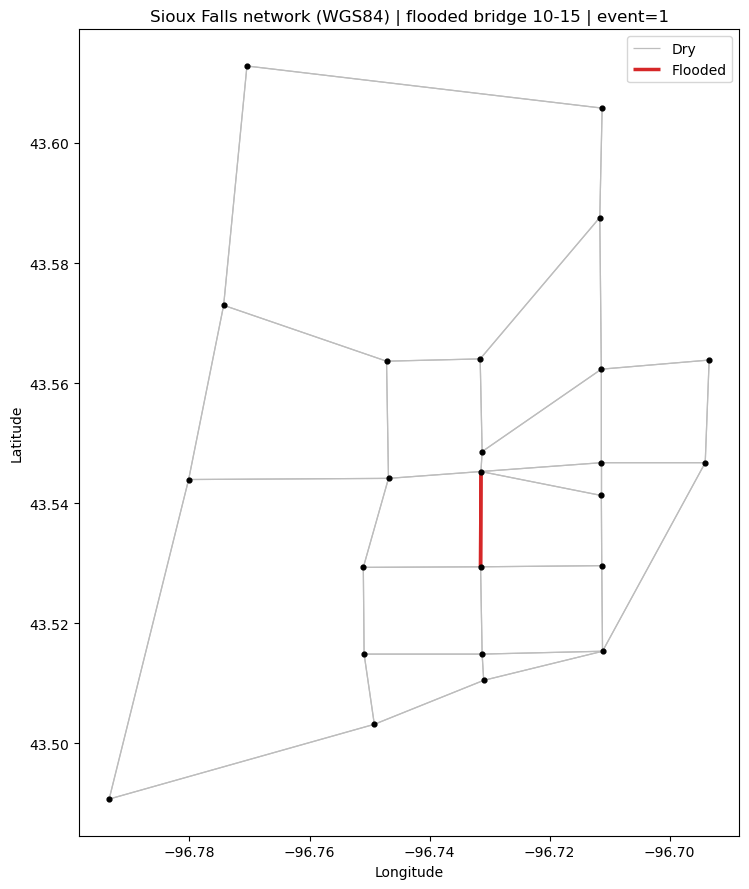

In [4]:
from shapely.geometry import Point

# Selected flood event to visualize (defaults to first available).
flood_key = int(os.getenv("NIRD_FLOOD_KEY", str(FLOOD_KEYS[0] if FLOOD_KEYS else 1)))

# Disrupted link geometry for this event (pipeline CRS = EPSG:9311 / CONUS Albers).
links_path = (
    results_root / "disruption_analysis" / VARIANT / str(DEPTH_KEY)
    / "links" / f"road_links_{flood_key}.gpq"
)
links = gpd.read_parquet(links_path)
links["flood_depth_max"] = pd.to_numeric(
    links.get("flood_depth_max", 0), errors="coerce"
).fillna(0)

# Plot in the official WGS84 layout (matches bstabler SiouxFallsCoordinates.geojson).
links_wgs84 = links.to_crs("EPSG:4326")

# Reference node overlay: prefer the vendored GeoJSON, fall back to parsing the TNTP file.
ref_geojson = root / "tests/data/sioux_falls_tntp/SiouxFallsCoordinates.geojson"
if ref_geojson.exists():
    ref_nodes = gpd.read_file(ref_geojson).to_crs("EPSG:4326")
else:
    node_tntp = root / "tests/data/sioux_falls_tntp/SiouxFalls_node.tntp"
    _rows = []
    for line in node_tntp.read_text(encoding="utf-8").splitlines():
        parts = line.strip().replace(";", "").split()
        if len(parts) >= 3 and parts[0].isdigit():
            _rows.append({"id": int(parts[0]), "x": float(parts[1]), "y": float(parts[2])})
    ref_nodes = gpd.GeoDataFrame(
        _rows,
        geometry=[Point(r["x"], r["y"]) for r in _rows],
        crs="EPSG:4326",
    )

fig, ax = plt.subplots(figsize=(9, 9))
dry = links_wgs84.loc[links_wgs84["flood_depth_max"] <= 0]
flooded = links_wgs84.loc[links_wgs84["flood_depth_max"] > 0]

dry.plot(ax=ax, color="#bdbdbd", linewidth=0.9, zorder=1, label="Dry")
if not flooded.empty:
    flooded.plot(ax=ax, color="#d62728", linewidth=2.5, zorder=2, label="Flooded")
ref_nodes.plot(ax=ax, color="black", markersize=12, zorder=3)

ax.set_title(f"Sioux Falls network (WGS84) | flooded bridge 10-15 | event={flood_key}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Link V/C map (final scenario, WGS84)

Post-reroute passenger edge flows (`edge_flows_passenger_s1_day1.gpq`) merged with disrupted-link capacity (`current_capacity` from `road_links_1.gpq`). V/C = flow / current_capacity, using the same logic as `visualize_pipeline_results.ipynb` Step 4B. Reference lines mark V/C = 0.8 and V/C = 1.0.

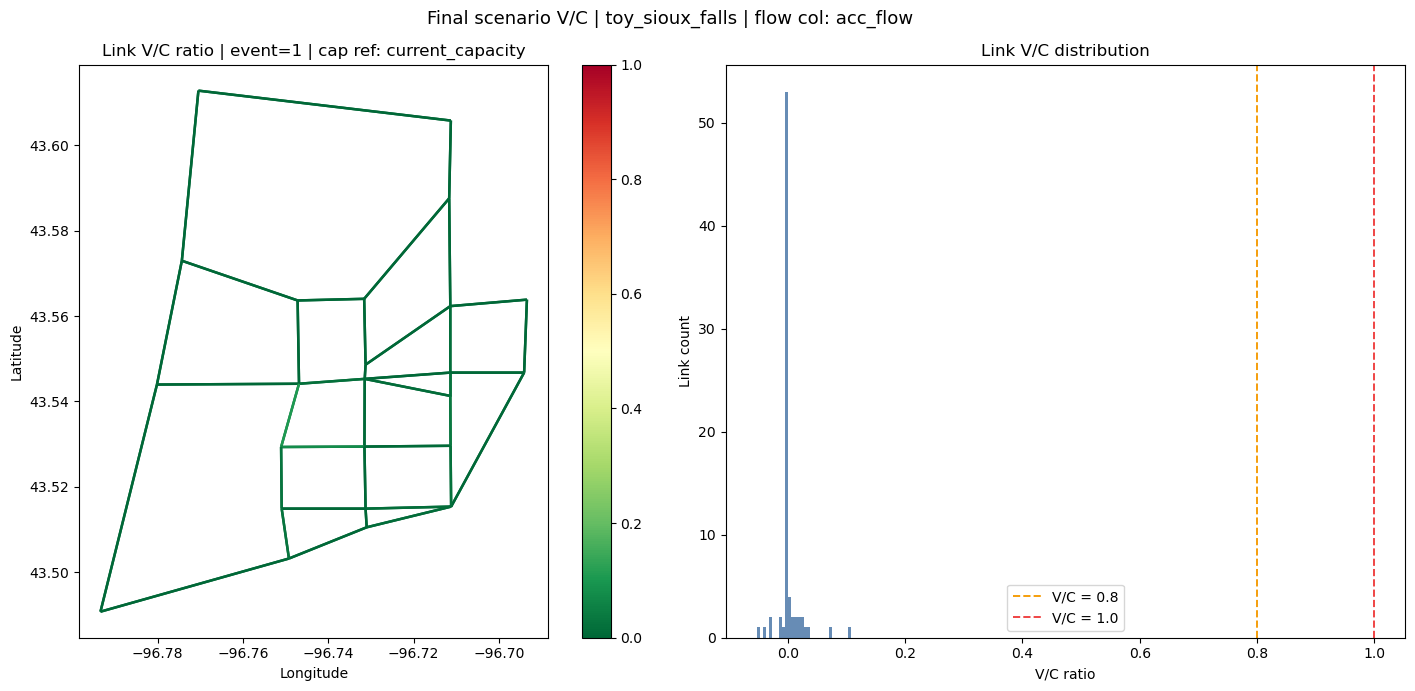

V/C source file : c:\Users\alimu\Desktop\Github\DAFNI-NIRD-sioux-falls-testbed\.pytest-tmp\test_sioux_falls_pipeline_scri0\results\rerouting_analysis\toy_sioux_falls\30\1\edge_flows_passenger_s1_day1.gpq
Flow column     : acc_flow
Capacity ref    : current_capacity
V/C summary     : mean=0.0027 median=0.0000 max=0.1084 over_1.0=0.00%


In [5]:
import numpy as np

# Post-reroute passenger edge flows for the selected event.
reroute_dir = results_root / "rerouting_analysis" / VARIANT / str(DEPTH_KEY) / str(flood_key)
edge_flows_path = reroute_dir / "edge_flows_passenger_s1_day1.gpq"
final_edges = gpd.read_parquet(edge_flows_path)

# Disrupted-link capacity for this event (fallback if edge flows lack current_capacity).
disrupted_links_path = (
    results_root / "disruption_analysis" / VARIANT / str(DEPTH_KEY)
    / "links" / f"road_links_{flood_key}.gpq"
)
disrupted_links = gpd.read_parquet(disrupted_links_path)

if "current_capacity" not in final_edges.columns and "current_capacity" in disrupted_links.columns:
    final_edges = final_edges.merge(
        disrupted_links[["e_id", "current_capacity"]], on="e_id", how="left"
    )

# Flow column (post-reroute accumulated flow), matching Step 4B.
flow_col = "acc_flow" if "acc_flow" in final_edges.columns else (
    "flow" if "flow" in final_edges.columns else "current_flow"
)
flow_vals = pd.to_numeric(final_edges[flow_col], errors="coerce")

# Capacity reference: prefer current_capacity, else acc_capacity + acc_flow.
if "current_capacity" in final_edges.columns:
    cap_ref = pd.to_numeric(final_edges["current_capacity"], errors="coerce")
    cap_source = "current_capacity"
elif {"acc_capacity", "acc_flow"}.issubset(final_edges.columns):
    cap_ref = (
        pd.to_numeric(final_edges["acc_capacity"], errors="coerce")
        + pd.to_numeric(final_edges["acc_flow"], errors="coerce")
    )
    cap_source = "acc_flow + acc_capacity"
else:
    raise ValueError("No usable capacity reference found for V/C computation.")

final_edges["vc_ratio"] = np.where(cap_ref > 0, flow_vals / cap_ref, np.nan)
final_edges["vc_ratio"] = pd.to_numeric(final_edges["vc_ratio"], errors="coerce")

vc_wgs84 = final_edges.to_crs("EPSG:4326")
valid_vc = vc_wgs84["vc_ratio"].replace([np.inf, -np.inf], np.nan).dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Left: spatial V/C choropleth.
vc_wgs84.plot(ax=axes[0], color="#e5e5e5", linewidth=0.6, zorder=1)
vc_wgs84.dropna(subset=["vc_ratio"]).plot(
    ax=axes[0],
    column="vc_ratio",
    cmap="RdYlGn_r",
    linewidth=1.8,
    legend=True,
    vmin=0.0,
    vmax=max(1.0, float(valid_vc.max()) if not valid_vc.empty else 1.0),
    zorder=2,
)
axes[0].set_title(f"Link V/C ratio | event={flood_key} | cap ref: {cap_source}")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_aspect("equal")

# Right: V/C distribution with reference lines at 0.8 and 1.0.
if not valid_vc.empty:
    axes[1].hist(valid_vc, bins=30, color="#4c78a8", alpha=0.85)
axes[1].axvline(0.8, color="#f59e0b", linestyle="--", linewidth=1.4, label="V/C = 0.8")
axes[1].axvline(1.0, color="#ef4444", linestyle="--", linewidth=1.4, label="V/C = 1.0")
axes[1].set_title("Link V/C distribution")
axes[1].set_xlabel("V/C ratio")
axes[1].set_ylabel("Link count")
axes[1].legend()

fig.suptitle(f"Final scenario V/C | {VARIANT} | flow col: {flow_col}", fontsize=13)
plt.tight_layout()
plt.show()

print(f"V/C source file : {edge_flows_path}")
print(f"Flow column     : {flow_col}")
print(f"Capacity ref    : {cap_source}")
if not valid_vc.empty:
    print(
        f"V/C summary     : mean={valid_vc.mean():.4f} median={valid_vc.median():.4f} "
        f"max={valid_vc.max():.4f} over_1.0={float((valid_vc > 1.0).mean() * 100):.2f}%"
    )

## Summary table

In [6]:
summary = build_scenario_summary_table(
    results_root,
    VARIANT,
    DEPTH_KEY,
    flood_keys=FLOOD_KEYS or None,
)
if summary.empty:
    raise FileNotFoundError(
        f"No disruption outputs under {results_root} for variant={VARIANT}, depth={DEPTH_KEY}"
    )

unit_hint = "KUSD (testbed)" if is_testbed_variant(VARIANT) else "MUSD (production-scale)"
print(f"Cost display: {unit_hint}")
display_cols = [
    "flood_key",
    "flooded_links",
    "closed_links",
    "damaged_links",
    "passenger_disrupted_flow",
    "freight_disrupted_flow",
    "rerouting_cost_passenger_display",
    "rerouting_cost_freight_display",
    "direct_damage_display",
    "combined_total_display",
    "isolation_rows",
    "passenger_flooded_edge_flow",
]
present = [c for c in display_cols if c in summary.columns]
summary[present]

Cost display: KUSD (testbed)


,flood_key,flooded_links,closed_links,damaged_links,passenger_disrupted_flow,freight_disrupted_flow,rerouting_cost_passenger_display,rerouting_cost_freight_display,direct_damage_display,combined_total_display,isolation_rows,passenger_flooded_edge_flow
0,1,2,2,2,17250.0,1552.5,$9.9K,$0.9K,$0.4K,$1.3K,0,-17250.0


## Scenario comparison charts

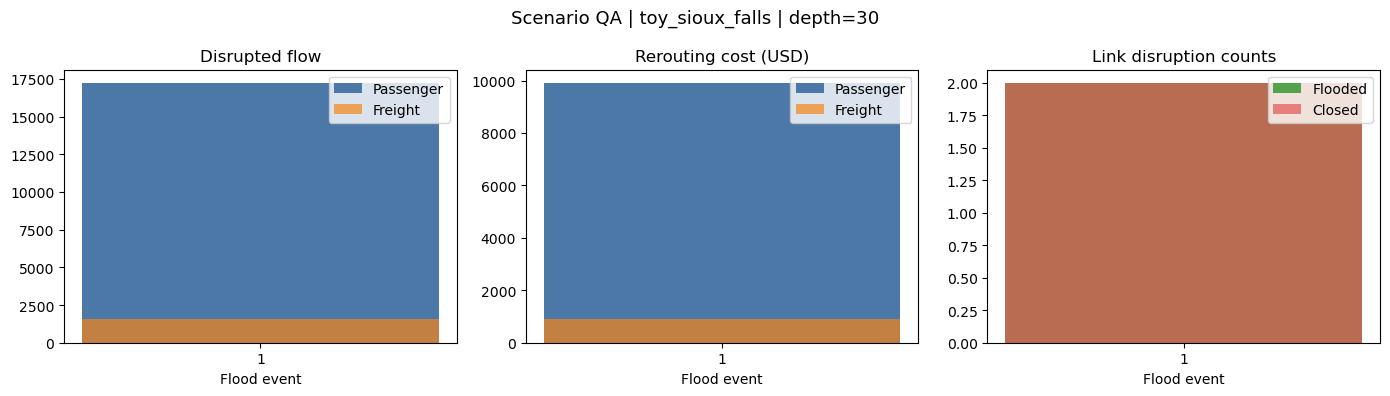

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x = summary["flood_key"].astype(str)

axes[0].bar(x, summary["passenger_disrupted_flow"], color="#4c78a8", label="Passenger")
axes[0].bar(x, summary["freight_disrupted_flow"], color="#f58518", alpha=0.7, label="Freight")
axes[0].set_title("Disrupted flow")
axes[0].set_xlabel("Flood event")
axes[0].legend()

axes[1].bar(x, summary["rerouting_cost_passenger_usd"], color="#4c78a8", label="Passenger")
axes[1].bar(x, summary["rerouting_cost_freight_usd"], color="#f58518", alpha=0.7, label="Freight")
axes[1].set_title("Rerouting cost (USD)")
axes[1].set_xlabel("Flood event")
axes[1].legend()

axes[2].bar(x, summary["flooded_links"], color="#54a24b", label="Flooded")
axes[2].bar(x, summary["closed_links"], color="#e45756", alpha=0.7, label="Closed")
axes[2].set_title("Link disruption counts")
axes[2].set_xlabel("Flood event")
axes[2].legend()

fig.suptitle(f"Scenario QA | {VARIANT} | depth={DEPTH_KEY}", fontsize=13)
fig.tight_layout()
plt.show()

## Flooded links map (selected event)

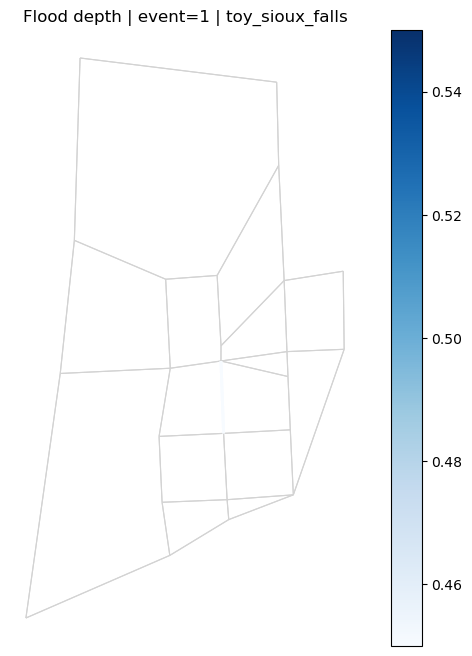

In [8]:
flood_key = int(os.getenv("NIRD_FLOOD_KEY", str(FLOOD_KEYS[0] if FLOOD_KEYS else 1)))
links_path = (
    results_root
    / "disruption_analysis"
    / VARIANT
    / str(DEPTH_KEY)
    / "links"
    / f"road_links_{flood_key}.gpq"
)
links = gpd.read_parquet(links_path)
links["flood_depth_max"] = pd.to_numeric(links.get("flood_depth_max", 0), errors="coerce").fillna(0)

fig, ax = plt.subplots(figsize=(8, 8))
links.loc[links["flood_depth_max"] <= 0].plot(ax=ax, color="#d3d3d3", linewidth=0.8, label="Dry")
flooded = links.loc[links["flood_depth_max"] > 0]
if not flooded.empty:
    flooded.plot(ax=ax, column="flood_depth_max", cmap="Blues", linewidth=2.0, legend=True)
ax.set_title(f"Flood depth | event={flood_key} | {VARIANT}")
ax.set_axis_off()
plt.show()

## Passenger reroute flow on flooded edges

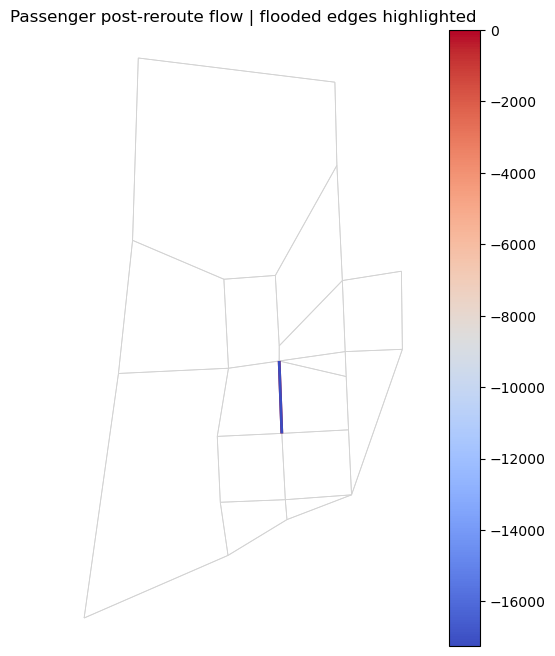

In [9]:
reroute_dir = results_root / "rerouting_analysis" / VARIANT / str(DEPTH_KEY) / str(flood_key)
post_path = reroute_dir / "edge_flows_passenger_s1_day1.gpq"
if not post_path.exists():
    print(f"Missing post-reroute flows: {post_path}")
else:
    post = gpd.read_parquet(post_path)
    flow_col = "acc_flow" if "acc_flow" in post.columns else "flow"
    post[flow_col] = pd.to_numeric(post[flow_col], errors="coerce").fillna(0)
    flooded_ids = set(links.loc[links["flood_depth_max"] > 0, "e_id"].astype(str))
    post["layer"] = post["e_id"].astype(str).map(
        lambda e: "flooded" if e in flooded_ids else "other"
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    post.loc[post["layer"] == "other"].plot(ax=ax, color="#d3d3d3", linewidth=0.6)
    subset = post.loc[post["layer"] == "flooded"]
    if not subset.empty:
        subset.plot(ax=ax, column=flow_col, cmap="coolwarm", linewidth=2.0, legend=True)
    ax.set_title(f"Passenger post-reroute flow | flooded edges highlighted")
    ax.set_axis_off()
    plt.show()